100000 comments verwerkt...
200000 comments verwerkt...
300000 comments verwerkt...
400000 comments verwerkt...
600000 comments verwerkt...
700000 comments verwerkt...
800000 comments verwerkt...
900000 comments verwerkt...
1000000 comments verwerkt...
1100000 comments verwerkt...
1200000 comments verwerkt...
1300000 comments verwerkt...
1400000 comments verwerkt...
1500000 comments verwerkt...
1600000 comments verwerkt...
1700000 comments verwerkt...
1800000 comments verwerkt...
[('russia', 181787), ('will', 163840), ('ukraine', 138354), ('war', 136313), ('israel', 118471), ('even', 108418), ('think', 107112), ('now', 86965), ('russian', 80606), ('know', 78959), ('time', 78316), ('right', 75884), ('country', 74878), ('much', 70987), ('going', 70339), ('way', 66544), ('world', 64568), ('well', 63917), ('make', 62221), ('good', 61838), ('see', 59977), ('years', 58228), ('military', 57500), ('hamas', 56963), ('say', 55260), ('putin', 55193), ('back', 53471), ('many', 53315), ('need', 527

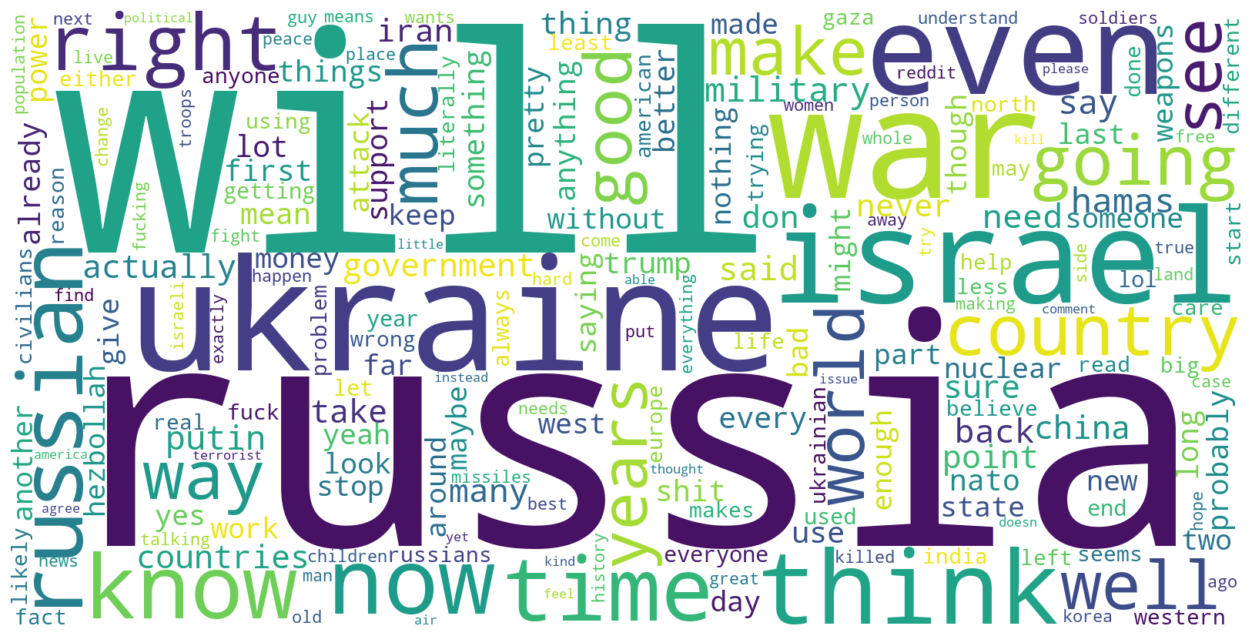

In [17]:
import json
import re
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

# pad naar je bestand
file_path = "./data/r_worldnews_comments.jsonl"

# extra stopwoorden
custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    "people", "article", "about", "want", "dont",
    "doesnt", "didnt", "theyre", "thats", "youre", "im", "aint",
    "get", "got", "one", "like", "would", "could", "really", "still"
])

word_counts = Counter()

with open(file_path, "r", encoding="utf-8") as f:
    for i, line in enumerate(f, start=1):
        try:
            comment = json.loads(line)
        except json.JSONDecodeError:
            continue  # sla kapotte regels over

        body = comment.get("body", "")
        if not isinstance(body, str):
            continue

        # verwijder deleted/removed comments
        if body.lower() in ["[deleted]", "[removed]"]:
            continue

        # lowercase
        body = body.lower()

        # links verwijderen
        body = re.sub(r"http\S+|www\S+", "", body)

        # enkel woorden behouden (apostrof mag blijven)
        words = re.findall(r"\b[a-zA-Z']+\b", body)

        # filter stopwoorden en heel korte woorden
        filtered_words = [
            w for w in words
            if w not in custom_stopwords and len(w) > 2
        ]

        word_counts.update(filtered_words)

        # optioneel: progress printen elke 100000 regels
        if i % 100000 == 0:
            print(f"{i} comments verwerkt...")

# toon topwoorden
print(word_counts.most_common(30))

# maak wordcloud op basis van frequenties
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color="white",
    collocations=False
).generate_from_frequencies(word_counts)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

# opslaan
wordcloud.to_file("reddit_wordcloud.png")

In [3]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\seppe\AppData\Roaming\nltk_data...


True

In [18]:
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

sentiment = sia.polarity_scores(body)
compound = sentiment["compound"]  # belangrijkste score (-1 tot 1)

In [19]:
import json
import re
from collections import Counter, defaultdict
from nltk.sentiment import SentimentIntensityAnalyzer

file_path = "./data/r_worldnews_comments.jsonl"

sia = SentimentIntensityAnalyzer()

daily_data = defaultdict(list)

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        try:
            comment = json.loads(line)
        except:
            continue

        body = comment.get("body", "")
        created_utc = comment.get("created_utc")

        if not isinstance(body, str):
            continue

        if body.lower() in ["[deleted]", "[removed]"]:
            continue

        # date (dag niveau)
        day = int(created_utc // 86400)  # unix → dag

        # clean text
        body_clean = body.lower()
        body_clean = re.sub(r"http\S+|www\S+", "", body_clean)

        # sentiment
        sentiment = sia.polarity_scores(body_clean)
        compound = sentiment["compound"]

        # candidate mentions
        trump = "trump" in body_clean
        harris = "harris" in body_clean or "kamala" in body_clean

        # save alles
        daily_data[day].append({
            "sentiment": compound,
            "trump": trump,
            "harris": harris,
            "length": len(body_clean)
        })

In [20]:
import numpy as np

features = []

for day, comments in daily_data.items():

    sentiments = [c["sentiment"] for c in comments]
    trump_comments = [c for c in comments if c["trump"]]
    harris_comments = [c for c in comments if c["harris"]]

    feature_row = {
        "day": day,
        "n_comments": len(comments),

        # algemene sentiment
        "avg_sentiment": np.mean(sentiments),
        "std_sentiment": np.std(sentiments),

        # polariteit
        "pos_ratio": sum(s > 0.05 for s in sentiments) / len(sentiments),
        "neg_ratio": sum(s < -0.05 for s in sentiments) / len(sentiments),

        # candidate mentions
        "trump_mentions": len(trump_comments),
        "harris_mentions": len(harris_comments),

        # share of voice
        "trump_share": len(trump_comments) / len(comments),
        "harris_share": len(harris_comments) / len(comments),
    }

    # sentiment per kandidaat
    if trump_comments:
        feature_row["trump_sentiment"] = np.mean([c["sentiment"] for c in trump_comments])
    else:
        feature_row["trump_sentiment"] = 0

    if harris_comments:
        feature_row["harris_sentiment"] = np.mean([c["sentiment"] for c in harris_comments])
    else:
        feature_row["harris_sentiment"] = 0

    # verschil = super sterke feature
    feature_row["sentiment_diff"] = (
        feature_row["trump_sentiment"] - feature_row["harris_sentiment"]
    )

    features.append(feature_row)

In [21]:
import pandas as pd

df = pd.DataFrame(features)

# sorteer op tijd
df = df.sort_values("day")

# maak echte datum (optioneel maar beter voor grafiek)
df["date"] = pd.to_datetime(df["day"], unit="D", origin="unix")

In [22]:
df["trump_smooth"] = df["trump_sentiment"].rolling(7).mean()
df["harris_smooth"] = df["harris_sentiment"].rolling(7).mean()

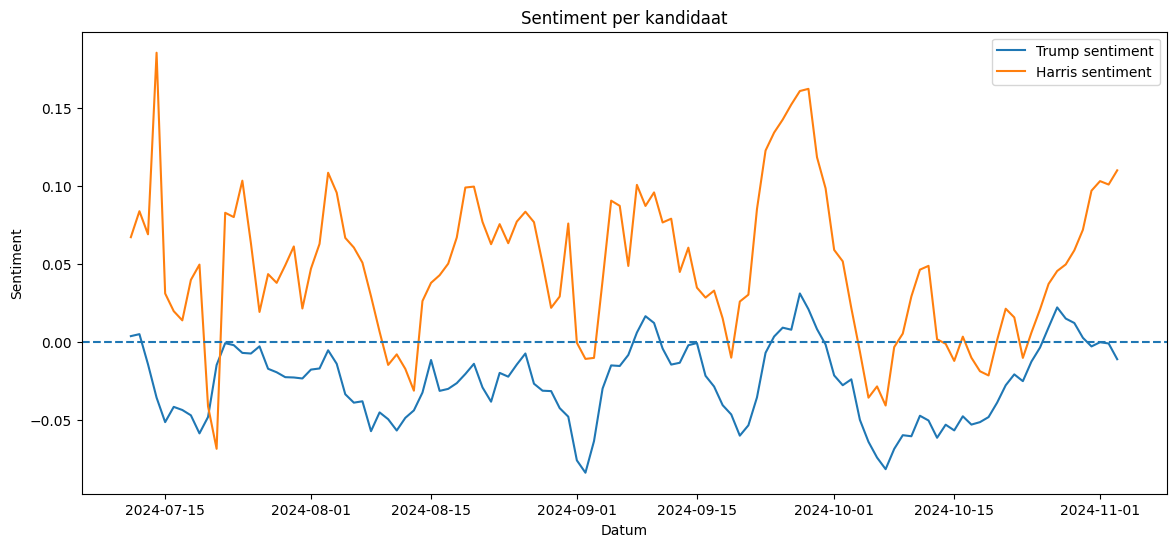

In [23]:
plt.figure(figsize=(14,6))

plt.plot(df["date"], df["trump_smooth"], label="Trump sentiment")
plt.plot(df["date"], df["harris_smooth"], label="Harris sentiment")

plt.axhline(0, linestyle="--")

plt.title("Sentiment per kandidaat")
plt.xlabel("Datum")
plt.ylabel("Sentiment")
plt.legend()

plt.show()

In [14]:
df["sent_diff_smooth"] = df["sentiment_diff"].rolling(7).mean()

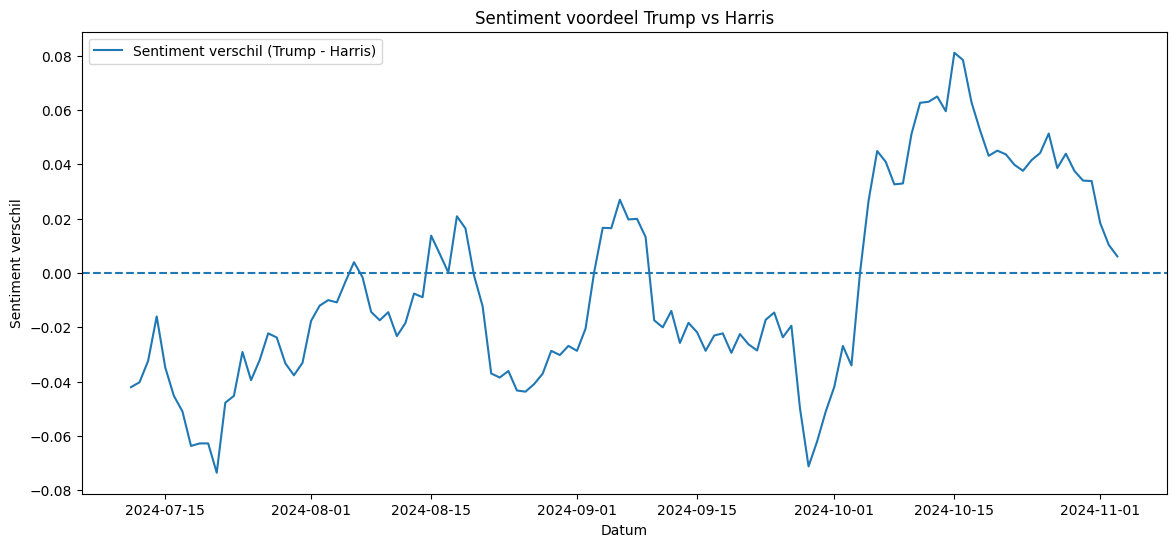

In [15]:
plt.figure(figsize=(14,6))

plt.plot(df["date"], df["sent_diff_smooth"], label="Sentiment verschil (Trump - Harris)")

plt.axhline(0, linestyle="--")

plt.title("Sentiment voordeel Trump vs Harris")
plt.xlabel("Datum")
plt.ylabel("Sentiment verschil")

plt.legend()
plt.show()

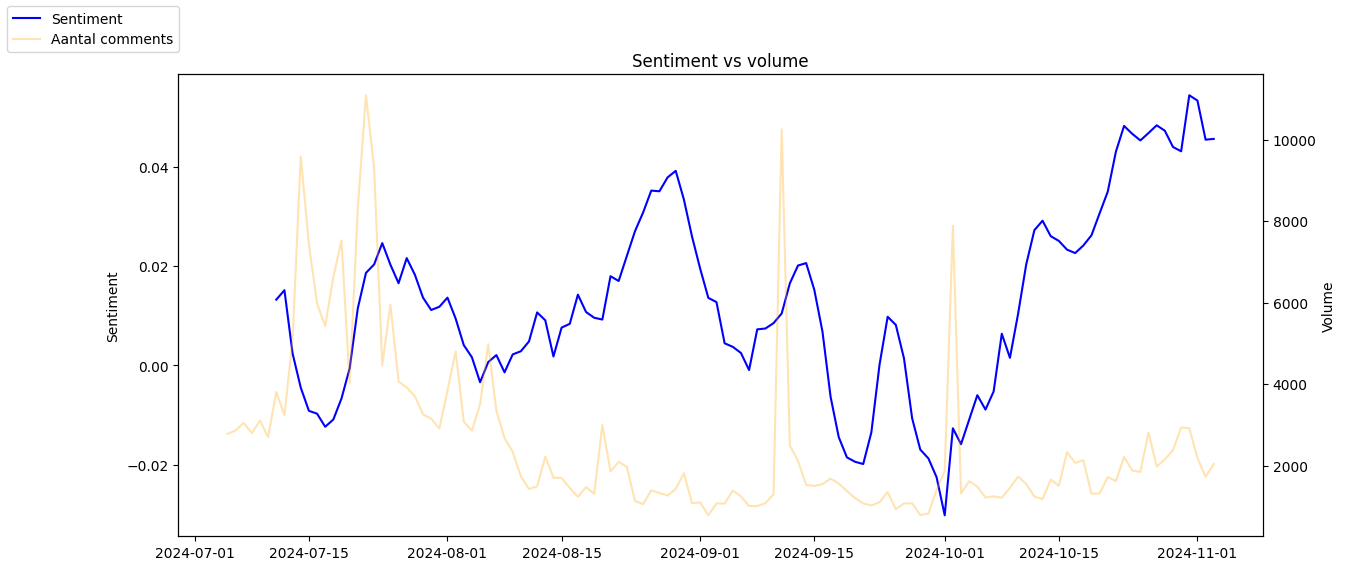

In [16]:
fig, ax1 = plt.subplots(figsize=(14,6))

ax1.plot(df["date"], df["sentiment_smooth"], label="Sentiment", color="blue")
ax1.set_ylabel("Sentiment")

ax2 = ax1.twinx()
ax2.plot(df["date"], df["n_comments"], label="Aantal comments", color="orange", alpha=0.3)
ax2.set_ylabel("Volume")

plt.title("Sentiment vs volume")
fig.legend(loc="upper left")

plt.show()

In [29]:
import json
import re
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download("vader_lexicon")
sia = SentimentIntensityAnalyzer()


files = {
    "conservative": "./data/r_conservative_comments.jsonl",
    "worldnews": "./data/r_worldnews_comments.jsonl",
    "democrats": "./data/r_democrats_comments.jsonl",
    "republican": "./data/r_trump_comments.jsonl",
}

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\seppe\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


## 2. Helper Functions

In [25]:
def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)   # links weg
    text = re.sub(r"\s+", " ", text).strip()     # extra spaties weg
    return text


def parse_comment_file(file_path, subreddit_name):
    rows = []

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                obj = json.loads(line)
            except json.JSONDecodeError:
                continue

            body = obj.get("body", "")
            if not isinstance(body, str):
                continue

            if body.lower() in ["[deleted]", "[removed]"]:
                continue

            created_utc = obj.get("created_utc")
            if created_utc is None:
                continue

            score = obj.get("score", 0)
            author = obj.get("author", None)

            body_clean = clean_text(body)
            if not body_clean:
                continue

            sentiment = sia.polarity_scores(body_clean)["compound"]

            rows.append({
                "subreddit": subreddit_name,
                "created_utc": created_utc,
                "datetime": pd.to_datetime(created_utc, unit="s", utc=True),
                "date": pd.to_datetime(created_utc, unit="s", utc=True).date(),
                "author": author,
                "score": score,
                "body": body,
                "body_clean": body_clean,
                "length_chars": len(body_clean),
                "length_words": len(body_clean.split()),
                "sentiment": sentiment,
                "mentions_trump": int("trump" in body_clean),
                "mentions_harris": int(("harris" in body_clean) or ("kamala" in body_clean)),
                "mentions_biden": int("biden" in body_clean),
            })

    return rows

## 3. Combine all

In [30]:
all_rows = []

for subreddit, file_path in files.items():
    print(f"Inladen: {subreddit}")
    rows = parse_comment_file(file_path, subreddit)
    all_rows.extend(rows)

df = pd.DataFrame(all_rows)

print(df.shape)
print(df.head())

Inladen: conservative
Inladen: worldnews
Inladen: democrats
Inladen: republican
(2363964, 14)
      subreddit  created_utc                  datetime        date  \
0  conservative   1720137650 2024-07-05 00:00:50+00:00  2024-07-05   
1  conservative   1720137670 2024-07-05 00:01:10+00:00  2024-07-05   
2  conservative   1720137719 2024-07-05 00:01:59+00:00  2024-07-05   
3  conservative   1720137721 2024-07-05 00:02:01+00:00  2024-07-05   
4  conservative   1720137742 2024-07-05 00:02:22+00:00  2024-07-05   

                 author  score  \
0      Sir_Creamz_Aloot      6   
1  ArgumentDramatic9279     18   
2          Ok_Goal_2716      1   
3     Kindly_Candle9809      7   
4               _Br549_     41   

                                                body  \
0  from the pic he's looking pretty orange from r...   
1  Nor will they ever, this debacle will serve as...   
2                                  Little California   
3                     Is this a real quote? Oh dear.   


In [31]:
df.to_parquet("reddit_full.parquet", index=False)